In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · Setup · Load · Baseline Correct · Filter · Smooth       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, find_peaks

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          12,
    'axes.labelsize':     13,
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'legend.fontsize':    11,
    'xtick.labelsize':    11,
    'ytick.labelsize':    11,
    'axes.linewidth':     1.3,
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.major.size':   5,
    'ytick.major.size':   5,
    'xtick.minor.size':   3,
    'ytick.minor.size':   3,
    'figure.dpi':         100,
})

# ── User-configurable constants ────────────────────────────────────────────────
DATA_DIR   = '.'
FILE_MAP   = {
    '40%': 'sec-10_power-40_i-10.xlsx',
    '50%': 'sec-10_power-50_i-10.xlsx',
    '60%': 'sec-10_power-60_i-10.xlsx',
    '70%': 'sec-10_power-70_i-10.xlsx',
}
COL_SHIFT     = 2        # 0-based column index for Raman shift
COL_INTENSITY = 3        # 0-based column index for intensity
SKIP_ROWS     = 1        # header rows to skip
X_MIN, X_MAX  = 500, 2000
SG_WINDOW     = 25       # Savitzky-Golay window (must be odd)
SG_ORDER      = 4        # Savitzky-Golay polynomial order
OUTPUT_DIR    = 'output_images'

COLORS = {
    '40%': '#1f77b4',
    '50%': '#d62728',
    '60%': '#2ca02c',
    '70%': '#9467bd',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Helper: ALS baseline correction ───────────────────────────────────────────
def als_baseline(y, lam=1e5, p=0.01, max_iter=10):
    m = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(m - 2, m))
    H = lam * D.T.dot(D)
    w = np.ones(m)
    for _ in range(max_iter):
        W = sparse.diags(w)
        z = spsolve(W + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

# ── Helper: normalise a 1-D array to [0, 1] ───────────────────────────────────
def normalise(y):
    y_max = y.max() if y.size > 0 else 1.0
    return y / y_max if y_max > 0 else y.copy()

# ── Helper: apply standard axis formatting ─────────────────────────────────────
def format_axes(ax):
    ax.set_xlim(X_MAX, X_MIN)
    ax.set_xlabel('Raman Shift (cm⁻¹)', labelpad=8)
    ax.set_ylabel('Intensity (a.u.)',    labelpad=8)
    ax.grid(True, which='major', linestyle='--',
            linewidth=0.5, alpha=0.45, color='grey', zorder=1)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load raw data
# ══════════════════════════════════════════════════════════════════════════════
print("Loading files...")
raw_data = {}
for label, fname in FILE_MAP.items():
    df  = pd.read_excel(os.path.join(DATA_DIR, fname),
                        header=None, skiprows=SKIP_ROWS)
    x   = pd.to_numeric(df.iloc[:, COL_SHIFT],     errors='coerce').values
    y   = pd.to_numeric(df.iloc[:, COL_INTENSITY],  errors='coerce').values
    valid = ~(np.isnan(x) | np.isnan(y))
    x, y  = x[valid], y[valid]
    idx   = np.argsort(x)
    raw_data[label] = (x[idx].copy(), y[idx].copy())
    print(f"  {label}  →  {valid.sum():,} pts  |  "
          f"{x[idx].min():.1f}–{x[idx].max():.1f} cm⁻¹")
print("All files loaded ✔\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — ALS baseline correction
# ══════════════════════════════════════════════════════════════════════════════
corrected_data = {}
for label, (x, y) in raw_data.items():
    bline           = als_baseline(y)
    corrected_data[label] = (x.copy(), np.clip(y - bline, 0, None))
    print(f"  {label}  max corrected: {corrected_data[label][1].max():,.1f}")
print("Baseline correction done ✔\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Spectral window filter  (X_MIN – X_MAX)
# ══════════════════════════════════════════════════════════════════════════════
filtered_data = {}
for label, (x, y) in corrected_data.items():
    mask = (x >= X_MIN) & (x <= X_MAX)
    filtered_data[label] = (x[mask].copy(), y[mask].copy())
    print(f"  {label}  →  {mask.sum():,} pts in {X_MIN}–{X_MAX} cm⁻¹")
print("Filtering done ✔\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Savitzky-Golay smoothing  (stored normalised for display)
# ══════════════════════════════════════════════════════════════════════════════
smoothed_data = {}          # label → (x, y_smoothed_normalised)
for label, (x_f, y_f) in filtered_data.items():
    y_s = savgol_filter(y_f, window_length=SG_WINDOW, polyorder=SG_ORDER)
    y_s = np.clip(y_s, 0, None)
    smoothed_data[label] = (x_f.copy(), normalise(y_s))
    print(f"  {label}  smoothed  (window={SG_WINDOW}, order={SG_ORDER})")
print("Savitzky-Golay smoothing done ✔\n")

print("=" * 60)
print("Cell 1 complete — raw_data, corrected_data, filtered_data,")
print("smoothed_data are ready for Cells 2 & 3.")
print("=" * 60)

Loading files...
  40%  →  2,048 pts  |  -46.2–2841.9 cm⁻¹
  50%  →  2,048 pts  |  -46.2–2841.9 cm⁻¹
  60%  →  2,048 pts  |  -46.2–2841.9 cm⁻¹
  70%  →  2,048 pts  |  -46.2–2841.9 cm⁻¹
All files loaded ✔

  40%  max corrected: 4,619.6
  50%  max corrected: 6,880.8
  60%  max corrected: 7,420.5
  70%  max corrected: 8,666.4
Baseline correction done ✔

  40%  →  993 pts in 500–2000 cm⁻¹
  50%  →  993 pts in 500–2000 cm⁻¹
  60%  →  993 pts in 500–2000 cm⁻¹
  70%  →  993 pts in 500–2000 cm⁻¹
Filtering done ✔

  40%  smoothed  (window=25, order=4)
  50%  smoothed  (window=25, order=4)
  60%  smoothed  (window=25, order=4)
  70%  smoothed  (window=25, order=4)
Savitzky-Golay smoothing done ✔

Cell 1 complete — raw_data, corrected_data, filtered_data,
smoothed_data are ready for Cells 2 & 3.


Saved → output_images/raman_combined.png  ✔


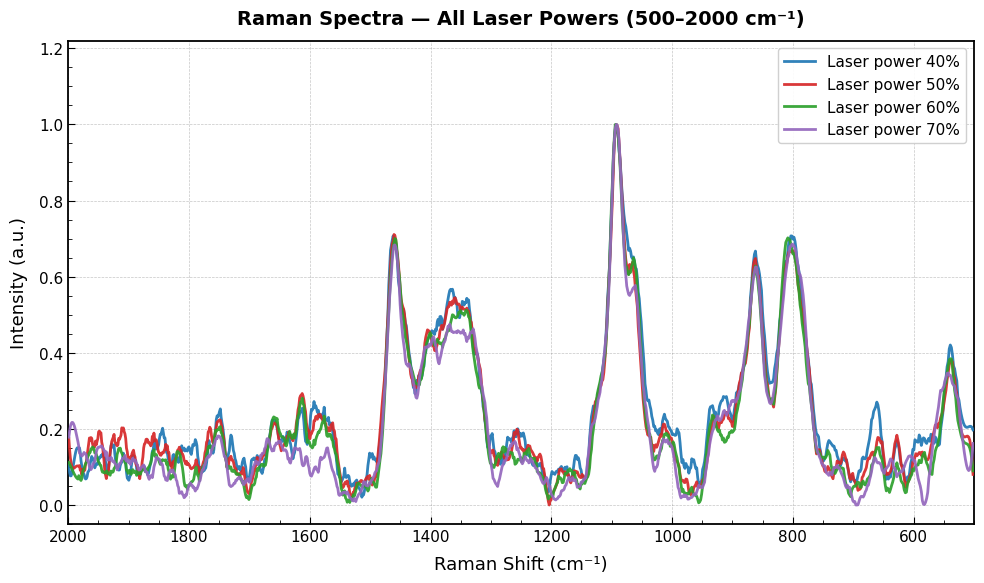

Saved → output_images/raman_combined_peaks.png  ✔


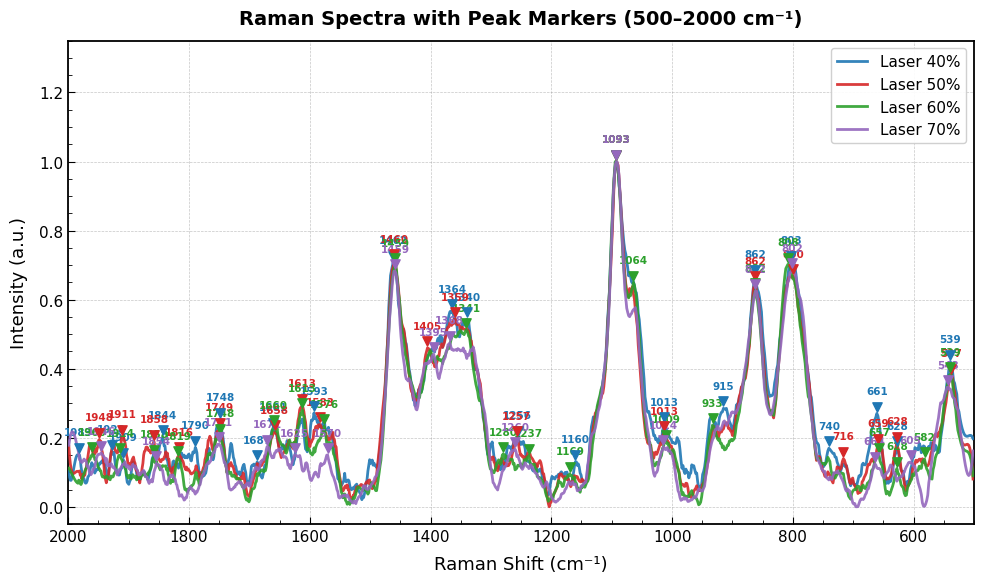

  Saved → output_images/raman_smoothed_power_40pct.png  ✔


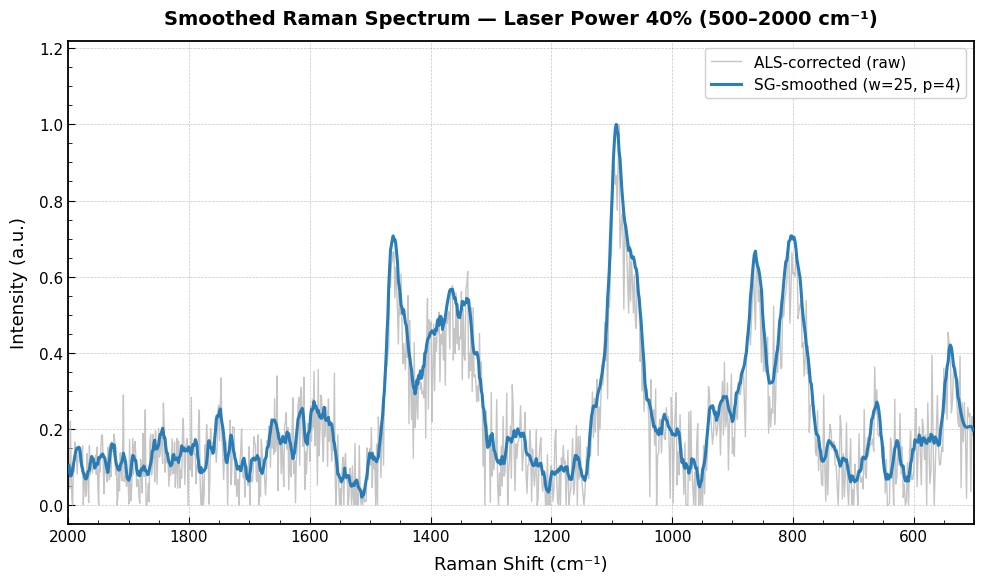

  Saved → output_images/raman_smoothed_power_50pct.png  ✔


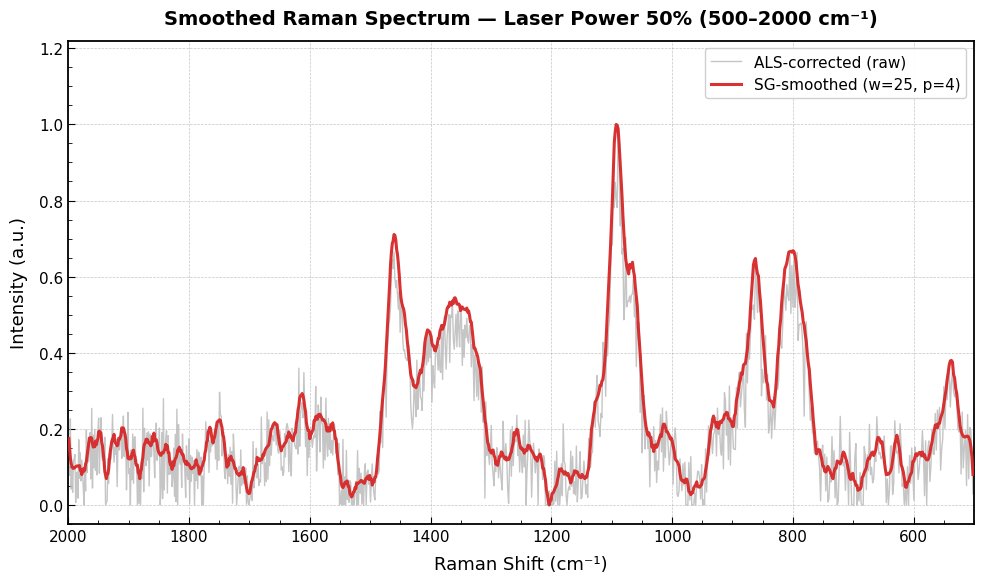

  Saved → output_images/raman_smoothed_power_60pct.png  ✔


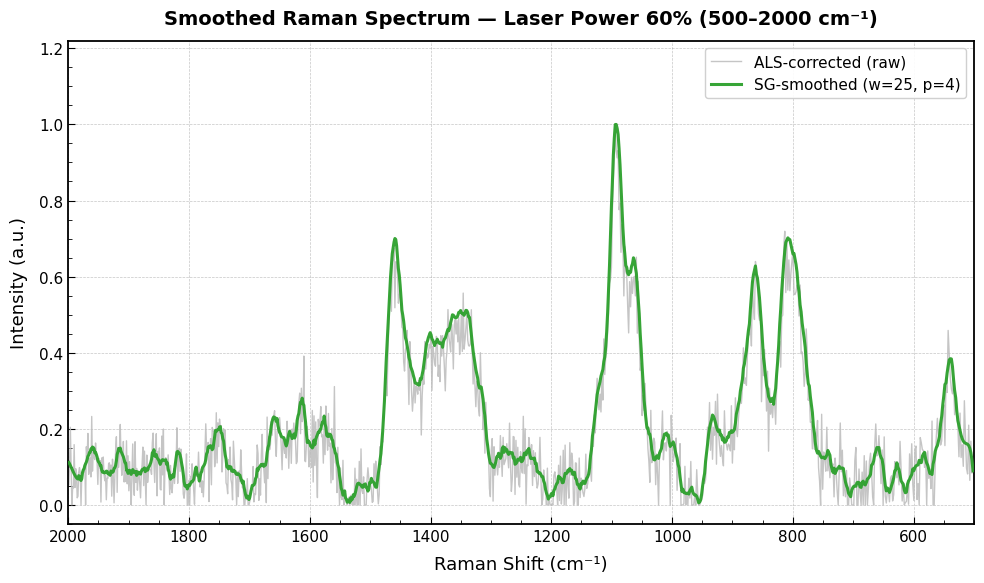

  Saved → output_images/raman_smoothed_power_70pct.png  ✔


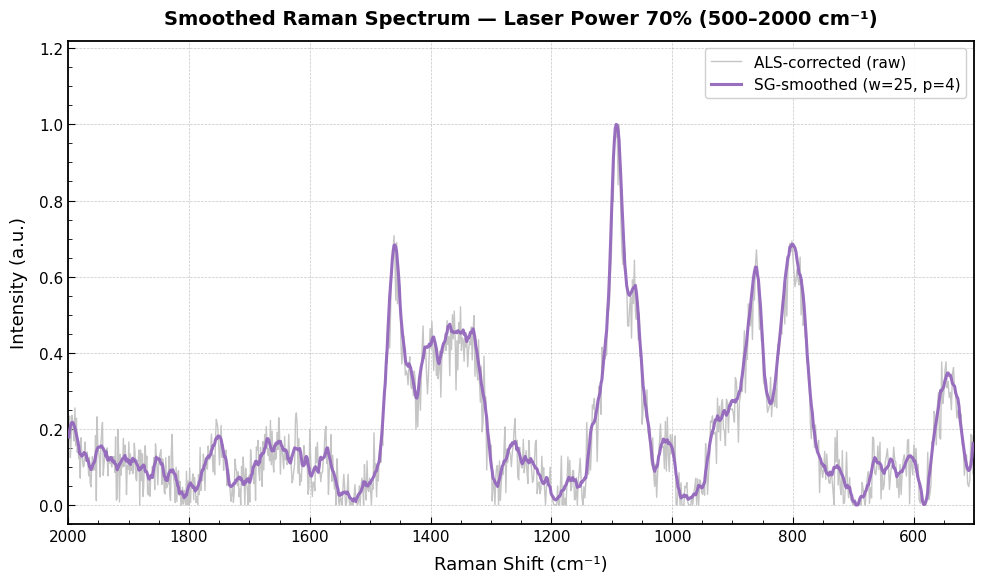


Saved 83 peaks → output_images/raman_peaks_table.csv  ✔


,Power,Raman Shift (cm⁻¹),Norm. Intensity,Prominence
0,40%,539.2,0.4204,0.2231
1,40%,627.7,0.1692,0.1016
2,40%,660.9,0.2703,0.2076
3,40%,740.3,0.1695,0.0549
4,40%,803.2,0.7071,0.6463
...,...,...,...,...
78,70%,1625.0,0.1502,0.0402
79,70%,1670.6,0.1743,0.1259
80,70%,1750.8,0.1813,0.1620
81,70%,1854.2,0.1257,0.0582


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Combined spectra · Individual spectra · Peak detection table      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 has been run (smoothed_data, filtered_data, COLORS, etc.)

PEAK_PROMINENCE = 0.04
PEAK_DISTANCE   = 15

# ══════════════════════════════════════════════════════════════════════════════
# PLOT A — Combined normalised spectra (all powers overlaid)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

for label, (x_f, y_norm) in smoothed_data.items():
    ax.plot(x_f, y_norm,
            color=COLORS[label], linewidth=2,
            label=f'Laser power {label}', alpha=0.92, zorder=3)

ax.set_ylim(-0.05, 1.22)
ax.set_title('Raman Spectra — All Laser Powers (500–2000 cm⁻¹)', pad=12)
format_axes(ax)
ax.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc', handlelength=2)
plt.tight_layout()
out_combined = f'{OUTPUT_DIR}/raman_combined.png'
fig.savefig(out_combined, dpi=300, bbox_inches='tight')
print(f'Saved → {out_combined}  ✔')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT B — Combined spectra with peak markers
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(10, 6))

all_peak_rows = []
for label, (x_f, y_norm) in smoothed_data.items():
    peaks, props = find_peaks(y_norm,
                              prominence=PEAK_PROMINENCE,
                              distance=PEAK_DISTANCE)
    ax2.plot(x_f, y_norm,
             color=COLORS[label], linewidth=2,
             label=f'Laser {label}', alpha=0.90, zorder=3)
    ax2.scatter(x_f[peaks], y_norm[peaks] + 0.02,
                color=COLORS[label], marker='v', s=45, zorder=5)
    for i, pk in enumerate(peaks):
        ax2.annotate(f'{x_f[pk]:.0f}',
                     xy=(x_f[pk], y_norm[pk] + 0.05),
                     ha='center', va='bottom', fontsize=7.5,
                     color=COLORS[label], fontweight='semibold')
        all_peak_rows.append({
            'Power':             label,
            'Raman Shift (cm⁻¹)': round(float(x_f[pk]), 1),
            'Norm. Intensity':   round(float(y_norm[pk]), 4),
            'Prominence':        round(float(props['prominences'][i]), 4),
        })

ax2.set_ylim(-0.05, 1.35)
ax2.set_title('Raman Spectra with Peak Markers (500–2000 cm⁻¹)', pad=12)
format_axes(ax2)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax2.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')
plt.tight_layout()
out_peaks = f'{OUTPUT_DIR}/raman_combined_peaks.png'
fig2.savefig(out_peaks, dpi=300, bbox_inches='tight')
print(f'Saved → {out_peaks}  ✔')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT C — Individual smoothed spectra (raw overlay in grey)
# ══════════════════════════════════════════════════════════════════════════════
for label, (x_f, y_norm_s) in smoothed_data.items():
    y_norm_r = normalise(filtered_data[label][1])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_f, y_norm_r,
            color='#bbbbbb', linewidth=1.0, alpha=0.85,
            label='ALS-corrected (raw)', zorder=2)
    ax.plot(x_f, y_norm_s,
            color=COLORS[label], linewidth=2.2,
            label=f'SG-smoothed (w={SG_WINDOW}, p={SG_ORDER})',
            alpha=0.95, zorder=3)

    ax.set_ylim(-0.05, 1.22)
    ax.set_title(f'Smoothed Raman Spectrum — Laser Power {label} (500–2000 cm⁻¹)', pad=12)
    format_axes(ax)
    ax.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')
    plt.tight_layout()

    out = f'{OUTPUT_DIR}/raman_smoothed_power_{label.replace("%", "pct")}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'  Saved → {out}  ✔')
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TABLE — Peak summary CSV
# ══════════════════════════════════════════════════════════════════════════════
peak_df = (pd.DataFrame(all_peak_rows)
           .sort_values(['Power', 'Raman Shift (cm⁻¹)'])
           .reset_index(drop=True))
csv_out = f'{OUTPUT_DIR}/raman_peaks_table.csv'
peak_df.to_csv(csv_out, index=False)
print(f'\nSaved {len(peak_df)} peaks → {csv_out}  ✔')
display(peak_df)

Saved → output_images/raman_functional_regions_combined.png  ✔


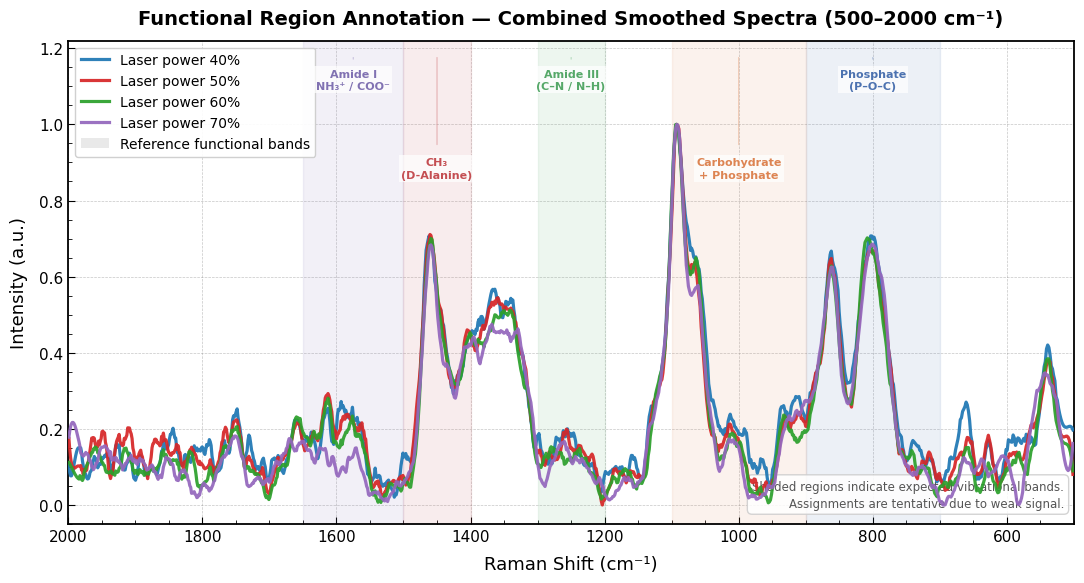

  Saved → output_images/raman_functional_regions_power_40pct.png  ✔


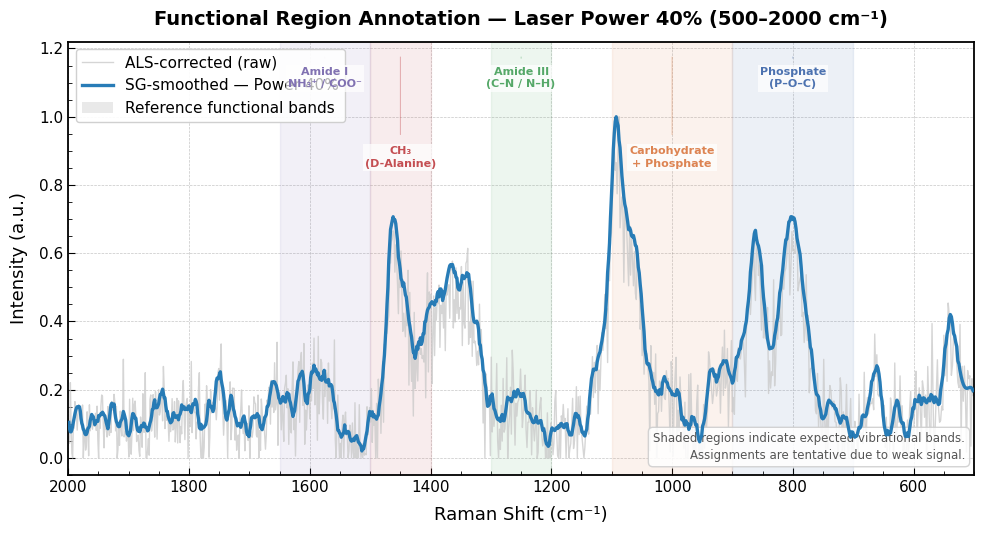

  Saved → output_images/raman_functional_regions_power_50pct.png  ✔


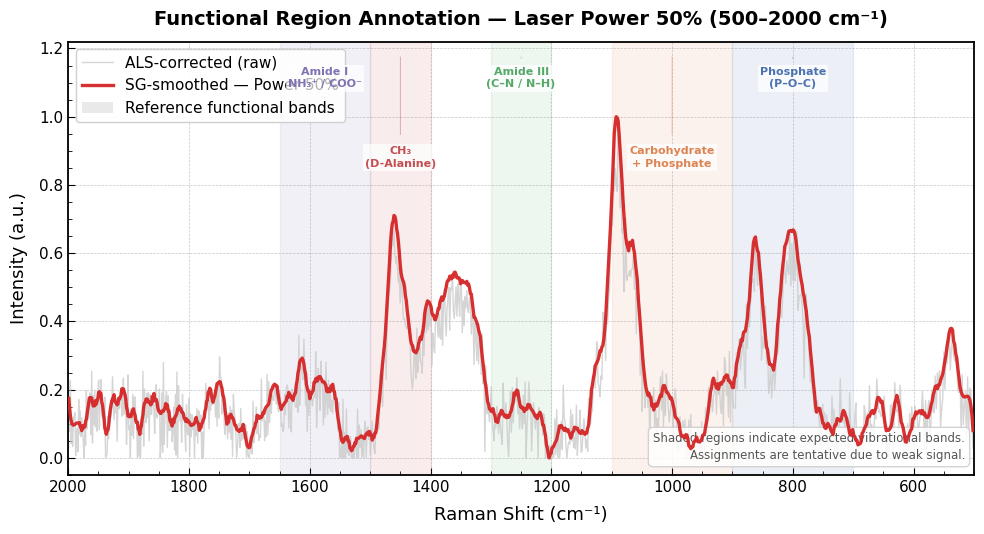

  Saved → output_images/raman_functional_regions_power_60pct.png  ✔


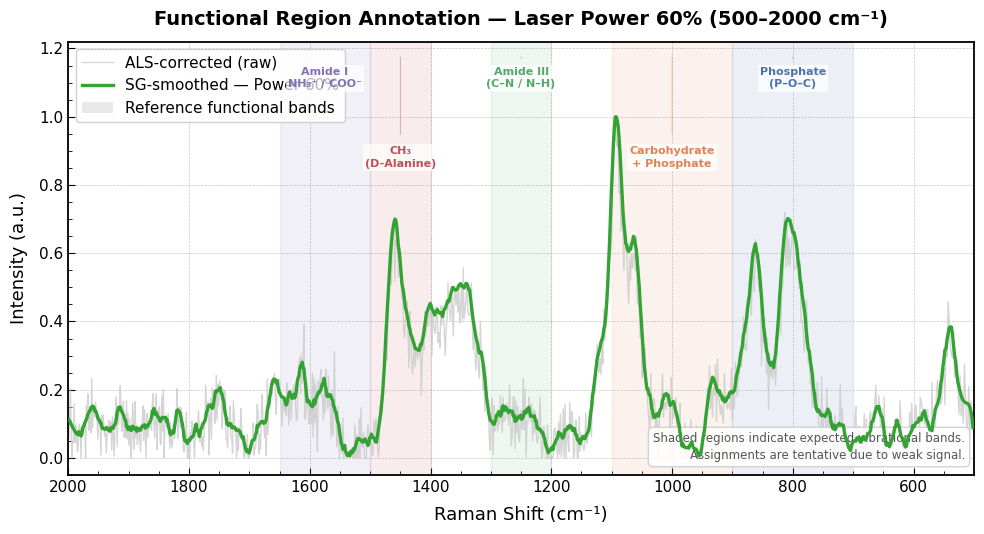

  Saved → output_images/raman_functional_regions_power_70pct.png  ✔


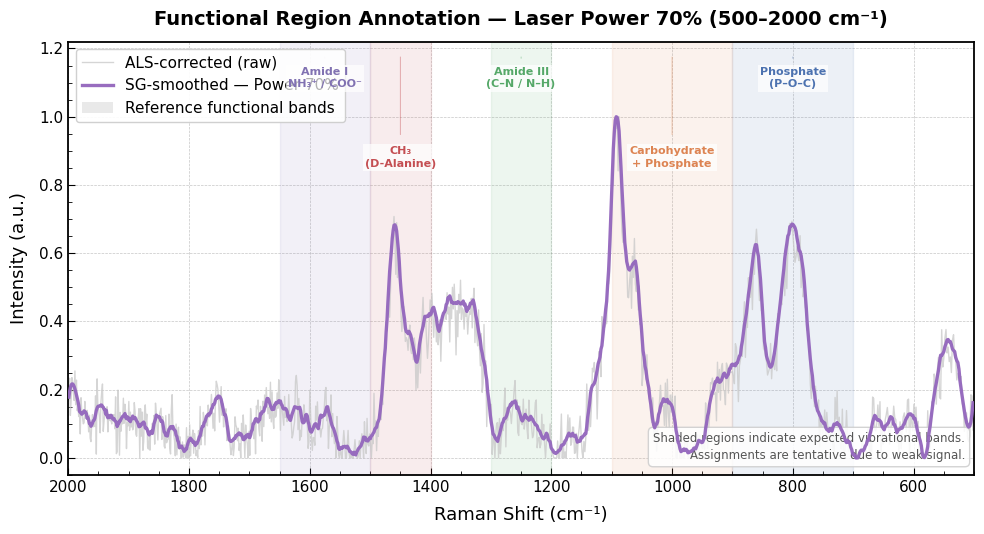


Cell 3 complete — all functional-region figures saved ✔


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Functional region annotation (no label overlap)                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Requires: Cell 1 has been run.

# ── Functional band definitions ────────────────────────────────────────────────
# Each entry: (start_cm, end_cm, short_label, hex_color)
REGIONS = [
    (700,  900,  'Phosphate\n(P–O–C)',         '#4C72B0'),
    (900,  1100, 'Carbohydrate\n+ Phosphate',   '#DD8452'),
    (1200, 1300, 'Amide III\n(C–N / N–H)',      '#55A868'),
    (1400, 1500, 'CH₃\n(D-Alanine)',            '#C44E52'),
    (1500, 1650, 'Amide I\nNH₃⁺ / COO⁻',       '#8172B2'),
]

NOTE = ('Shaded regions indicate expected vibrational bands.\n'
        'Assignments are tentative due to weak signal.')

# proxy patch for the legend
region_proxy = Patch(facecolor='#8a8a8a', edgecolor='none',
                     alpha=0.18, label='Reference functional bands')


def add_region_bands(ax, y_top, alternating=True):
    """
    Draw shaded axvspan bands and stagger their text labels vertically
    so they never overlap even at similar x positions.
    y_top  : upper data-coordinate limit of the axes
    alternating : if True, odd regions get label at y_top*0.93,
                  even regions at y_top*0.78  → two-row stagger
    """
    for i, (start, end, label, color) in enumerate(REGIONS):
        ax.axvspan(start, end, color=color, alpha=0.10, zorder=1)
        x_mid = (start + end) / 2

        # Two-row stagger: alternate between upper and lower label row
        y_lbl = y_top * (0.94 if i % 2 == 0 else 0.75)

        ax.text(
            x_mid, y_lbl, label,
            ha='center', va='top',
            fontsize=8, fontweight='bold',
            color=color, linespacing=1.35,
            bbox=dict(facecolor='white', edgecolor='none',
                      alpha=0.70, pad=1.5),
            zorder=6,
        )

        # Draw a thin dashed guide line from the band centre to the label
        ax.annotate(
            '', xy=(x_mid, y_top * (0.96 if i % 2 == 0 else 0.77)),
            xytext=(x_mid, y_top * 0.97),
            arrowprops=dict(arrowstyle='-', color=color,
                            lw=0.6, alpha=0.5),
            zorder=5,
        )


# ══════════════════════════════════════════════════════════════════════════════
# PLOT D — Combined smoothed spectra + region bands
# ══════════════════════════════════════════════════════════════════════════════
Y_LIM_TOP = 1.22
fig, ax = plt.subplots(figsize=(11, 6))

for label, (x_f, y_norm_s) in smoothed_data.items():
    ax.plot(x_f, y_norm_s,
            color=COLORS[label], linewidth=2.3,
            label=f'Laser power {label}', alpha=0.93, zorder=4)

add_region_bands(ax, y_top=Y_LIM_TOP)

ax.set_ylim(-0.05, Y_LIM_TOP)
ax.set_title('Functional Region Annotation — Combined Smoothed Spectra (500–2000 cm⁻¹)',
             pad=12)
format_axes(ax)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

handles, labels_leg = ax.get_legend_handles_labels()
handles.append(region_proxy)
labels_leg.append(region_proxy.get_label())
ax.legend(handles, labels_leg,
          loc='upper left', framealpha=0.92, edgecolor='#cccccc',
          fontsize=10)

# Note text in bottom-right corner (inside axes, never overlaps spectra)
ax.text(0.99, 0.03, NOTE,
        transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8.5,
        color='#555555', linespacing=1.4,
        bbox=dict(facecolor='white', edgecolor='#cccccc',
                  alpha=0.85, pad=4, boxstyle='round,pad=0.4'))

plt.tight_layout()
out_comb = f'{OUTPUT_DIR}/raman_functional_regions_combined.png'
fig.savefig(out_comb, dpi=300, bbox_inches='tight')
print(f'Saved → {out_comb}  ✔')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT E — Individual smoothed spectra + region bands (one per power level)
# ══════════════════════════════════════════════════════════════════════════════
for label, (x_f, y_norm_s) in smoothed_data.items():
    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.plot(x_f, normalise(filtered_data[label][1]),
            color='#c8c8c8', linewidth=1.0, alpha=0.75,
            label='ALS-corrected (raw)', zorder=2)
    ax.plot(x_f, y_norm_s,
            color=COLORS[label], linewidth=2.4,
            label=f'SG-smoothed — Power {label}',
            alpha=0.96, zorder=4)

    add_region_bands(ax, y_top=Y_LIM_TOP)

    ax.set_ylim(-0.05, Y_LIM_TOP)
    ax.set_title(f'Functional Region Annotation — Laser Power {label} (500–2000 cm⁻¹)',
                 pad=12)
    format_axes(ax)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

    handles, labels_leg = ax.get_legend_handles_labels()
    handles.append(region_proxy)
    labels_leg.append(region_proxy.get_label())
    ax.legend(handles, labels_leg,
              loc='upper left', framealpha=0.92, edgecolor='#cccccc')

    ax.text(0.99, 0.03, NOTE,
            transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8.5, color='#555555',
            linespacing=1.4,
            bbox=dict(facecolor='white', edgecolor='#cccccc',
                      alpha=0.85, pad=4, boxstyle='round,pad=0.4'))

    plt.tight_layout()
    out = f'{OUTPUT_DIR}/raman_functional_regions_power_{label.replace("%", "pct")}.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'  Saved → {out}  ✔')
    plt.show()

print('\nCell 3 complete — all functional-region figures saved ✔')